In [1]:
import os
os.chdir('../..')

In [2]:
import json
import matplotlib.pyplot as plt

from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.core import Structure
from ase import Atoms

from src.datasets import MaterialsProject
from src.non_euclidean import Grassmann, Riemann, PersistentHomology, Wasserstein
from src.helper_functions import get_distances

In [3]:
mp = MaterialsProject()
mp.load()

2026-03-09 12:52:56.386 | INFO     | src.datasets:load:650 - Loading cached Parquet data from data/Materials Project/stable_oxides.parquet...


material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,acsf_embedding,soap_embedding
str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64]
"""mp-1274279""","""FeO""",-8.19051,-1.481519,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",5.614899,3.102294,5.375696,5.443817,110.556657,91.096992,89.9466,84.988477,8,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-19921""","""PbO""",-5.800276,-1.469972,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",8.810225,3.999514,3.999514,5.259816,90.0,90.0,90.0,84.136627,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-2097""","""SnO""",-6.108469,-1.629702,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",6.294343,3.813695,3.813695,4.8869133,90.0,90.0,90.0,71.076593,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-1692""","""CuO""",-5.466379,-0.942795,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",6.1556,2.879501,2.879545,5.176397,89.806512,89.806349,89.222525,42.916449,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
"""mp-1336""","""PdO""",-5.853748,-0.789826,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",8.117606,3.053604,3.053604,5.371257,90.0,90.0,90.0,50.084274,4,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""mp-24129""","""MnH4(BrO)2""",-5.299537,-1.309259,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.976894,3.963651,6.006202,6.006203,95.912312,96.949439,96.949428,139.885532,9,"[4.619654, 0.736364, … 0.0]","[0.100292, 0.26796, … 0.0]"
"""mp-23880""","""FeH4(ClO)2""",-5.265791,-1.305381,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.287095,5.714367,5.714367,3.721117,82.486963,82.486963,97.148948,118.187118,9,"[5.545048, 0.773538, … 0.0]","[0.100956, 0.268515, … 0.0]"
"""mp-23853""","""CoH4(ClO)2""",-5.045306,-1.233407,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.424991,3.603494,5.686069,5.686069,97.465063,96.908777,96.908772,113.58114,9,"[5.775085, 0.776909, … 0.0]","[0.101054, 0.268578, … 0.0]"


In [ ]:
R_CUTOFF = 15.0
adaptor = AseAtomsAdaptor()

frames_unit = [] 
frames_ph = []   
for struct_json in mp.df["raw_structure"]:
    struct = Structure.from_dict(json.loads(struct_json))
    prim = struct.get_primitive_structure()
    frames_unit.append(adaptor.get_atoms(prim))

    center_index = 0
    neighbors = struct.get_all_neighbors(r=R_CUTOFF, sites=[struct[center_index]])[0]
    
    pos = [struct[center_index].coords]
    symbols = [struct[center_index].species_string]
    
    for neighbor in neighbors:
        pos.append(neighbor.coords)
        symbols.append(neighbor.species_string)
    
    cloud = Atoms(symbols=symbols, positions=pos)
    frames_ph.append(cloud)

dist_matrices = get_distances(frames_unit, frames_ph, dataset='Materials Project/distance_matrices')

2026-03-09 12:53:00.018 | INFO     | src.helper_functions:get_distances:116 - Using PH frames
2026-03-09 12:53:00.018 | INFO     | src.helper_functions:get_distances:126 - Loading grassmann_qr distance matrix...
2026-03-09 12:53:00.022 | INFO     | src.helper_functions:get_distances:126 - Loading grassmann_svd distance matrix...
2026-03-09 12:53:00.027 | INFO     | src.helper_functions:get_distances:126 - Loading euclidean_riemann distance matrix...
2026-03-09 12:53:00.031 | INFO     | src.helper_functions:get_distances:126 - Loading affine_riemann distance matrix...
2026-03-09 12:53:00.034 | INFO     | src.helper_functions:get_distances:126 - Loading wasserstein distance matrix...
2026-03-09 12:53:00.038 | INFO     | src.helper_functions:get_distances:129 - Computing ph_bottleneck distance matrix...
2026-03-09 12:53:00.039 | INFO     | src.non_euclidean:distance_matrix:141 - Computing persistent homology distance matrix for 1000 frames (backend='ripser', metric='bottleneck', max_homol

# Grassmann

In [ ]:
dist_matrix = Grassmann.distance_matrix()

2026-03-09 11:38:40.894 | INFO     | src.non_euclidean:distance_matrix:220 - Computing Grassmann distance matrix for 1000 frames (k=3, method='svd').
Grassmann distances: 100%|██████████| 499500/499500 [00:33<00:00, 14906.65pair/s]
2026-03-09 11:39:14.515 | DEBUG    | src.non_euclidean:distance_matrix:235 - Finished Grassmann distance matrix computation.


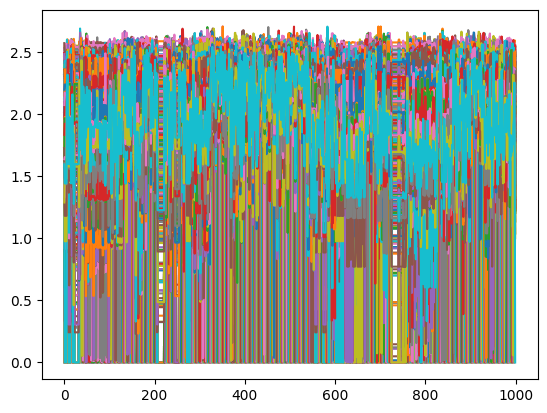

In [ ]:
plt.plot(dist_matrix)
plt.show()